In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pymc as pm 
import arviz as az

In [2]:
df = pd.read_csv("U.S._Chronic_Disease_Indicators__CDI___2023_Release.csv")

/tmp/ipykernel_1931/3194276456.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("U.S._Chronic_Disease_Indicators__CDI___2023_Release.csv")


# Project Title: Uncovering the True Asthma Burden: A Bayesian Hierarchical Analysis

## Introduction & Research Question
Asthma remains a critical public health challenge in the United States, yet quantifying its burden at the state level is complicated by statistical noise and data irregularities. Standard surveillance data often presents a misleading picture: states with smaller populations or lower case counts exhibit high variance, resulting in unreliable "raw" estimates. Furthermore, the available data is often **unbalanced**, with reporting gaps or data suppression for certain years and states.

To address these challenges, we move beyond descriptive statistics to **Bayesian Hierarchical Modeling (BHM)**. By treating state-level data as realized observations from a broader national distribution, we can robustly estimate disease burden even in the presence of sparse or missing data.

> **Research Question:**
> After accounting for sampling variability, demographic confounding, and data sparsity, what are the **robust, latent estimates** of age-adjusted asthma hospitalization rates across U.S. states? Which states exhibit a significantly elevated burden compared to the national average?

##  Methodology: Why Bayesian Hierarchical Modeling?
We employ a **Normal-Normal Probabilistic Model** to infer the latent hospitalization rate ($\theta_i$) for each state. This approach was specifically chosen to address the **unbalanced nature** of our dataset.

**Handling Unbalanced Panels & Missingness**
Our dataset is an "unbalanced panel," meaning not all states have data available for every year (e.g., due to CDC suppression of low counts). Traditional frequentist methods often require balanced datasets or involve imputing missing values with means, which can introduce bias and artificial certainty.
The Bayesian framework offers a superior solution:
* **No Imputation Needed:** We treat the valid observations for each state as repeated measurements of that state's true parameter. The model does not require a fixed number of years per state; it naturally accepts "ragged" data structures.
* **Partial Pooling:** For states with sparse data (few reported years) or high variance, the model automatically "shrinks" estimates towards the national mean (the prior). This allows us to retain all valid observations without discarding states with partial records, ensuring we maximize the use of available information while honestly quantifying uncertainty.

##  Data Selection Rationale
Our analysis strictly utilizes **Age-Adjusted Hospitalization Rates (Overall)** based on the following criteria:

* **The "Goldilocks" Metric:** We focus on **hospitalization rates** because they represent a balance between severity and data density. Unlike mortality rates (which are too rare/sparse for stable modeling) and ED visits (which are confounded by healthcare access), hospitalization rates reflect clinically significant, uncontrolled asthma.
* **Removing Demographic Confounding:** We use **Age-Adjusted Rates** rather than crude rates. This removes the confounding effect of age structure (e.g., older populations naturally having higher rates), ensuring that comparisons reflect true disease burden rather than demographics.
* **Ensuring Independence:** We restrict our analysis to **"Overall"** stratification, filtering out gender and race subgroups. This prevents double-counting and satisfies the independence assumptions required for the hierarchical model structure.

In [3]:
df.columns

Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'DataSource',
       'Topic', 'Question', 'Response', 'DataValueUnit', 'DataValueType',
       'DataValue', 'DataValueAlt', 'DataValueFootnoteSymbol',
       'DatavalueFootnote', 'LowConfidenceLimit', 'HighConfidenceLimit',
       'StratificationCategory1', 'Stratification1', 'StratificationCategory2',
       'Stratification2', 'StratificationCategory3', 'Stratification3',
       'GeoLocation', 'ResponseID', 'LocationID', 'TopicID', 'QuestionID',
       'DataValueTypeID', 'StratificationCategoryID1', 'StratificationID1',
       'StratificationCategoryID2', 'StratificationID2',
       'StratificationCategoryID3', 'StratificationID3'],
      dtype='object')

In [4]:
df['YearStart'].unique()

array([2014, 2018, 2017, 2010, 2015, 2013, 2016, 2020, 2012, 2019, 2011,
       2008, 2009, 2021])

### Data Cleaning

- Filter out all data that are unavalible （foot note = No data available)

- Extract the rows related to the RQ

  - Asthma
  - hospitalization
  - Age adjusted rate

We focus on age-adjusted asthma hospitalization rates because they provide the most reliable, comparable, and interpretable measure of asthma burden in this dataset. Hospitalizations occur frequently enough to yield stable estimates and reflect clinically meaningful exacerbations that indicate poor asthma control. Using age-adjusted rates is essential because states differ widely in age structure, and older populations naturally have higher hospitalization risk. Age adjustment removes this demographic effect, ensuring that differences across states reflect true asthma burden rather than population age differences. In contrast, asthma mortality is too rare for stable modeling, and emergency-department visits are heavily influenced by healthcare access rather than underlying disease severity. This makes age-adjusted hospitalization rates the most appropriate outcome for our hierarchical Bayesian analysis.
    
    - overall stratification categories
We use Overall rates because our goal is to compare asthma burden across states at the population level. Race- or gender-specific rates reflect subgroup patterns, not statewide rates, and differ in sample size and variability. Restricting to Overall data ensures consistent population units and satisfies the assumptions of the hierarchical model.

- Drop missing value of DataValue where the footnote is "Data not shown because of too few respondents or cases"

We removed rows with suppressed data (labeled as 'too few cases') to avoid introducing imputation bias. Our Bayesian hierarchical model naturally handles unbalanced datasets, allowing us to estimate parameters using only the valid reported years for each state.
  

In [5]:
#----------------------
#Filter out all data that are unavalible 
#----------------------
df = df[df['DatavalueFootnote'] != 'No data available']


#----------------------
#Extract the rows
#----------------------
#Extract the rows related to the RQ
asth = df[
    (df["Topic"] == "Asthma") &
    (df["Question"] == "Hospitalizations for asthma") &
    (df["DataValueType"] == "Age-adjusted Rate") &
    (df['StratificationCategoryID1'] == "OVERALL")
].copy()

#removed rows with suppressed data
asth = asth[asth["DataValue"].notna()]


#----------------------
#Check others feature
#----------------------
col_need = ['YearStart', 'YearEnd','LocationAbbr','LocationDesc','DataValueUnit', 'DataValue','LowConfidenceLimit', 'HighConfidenceLimit']

asth = asth[col_need]
if asth.isna().values.any():
    print("Have Missing Value")

#Check if all the data are from within the year
if (asth['YearStart'] != asth['YearEnd']).any():
    print("There are data spanning multiple years")

#Check abbr are valid
valid_abbr = {
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA",
    "HI","ID","IL","IN","IA","KS","KY","LA","ME","MD",
    "MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
    "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC",
    "SD","TN","TX","UT","VT","VA","WA","WV","WI","WY",
    "DC"
}
used_abbr = set(asth["LocationAbbr"].unique())
invalid = used_abbr - valid_abbr
if invalid:
    print("Found invalid LocationAbbr:", invalid)

#Check is there only one type o f DataValueUnit
if len(asth['DataValueUnit'].unique()) != 1:
    print("Multiple type of data value unit")

#correct the data types of numerical feature
asth["DataValue"] = pd.to_numeric(asth["DataValue"], errors="coerce")
asth["LowConfidenceLimit"]  = pd.to_numeric(asth["LowConfidenceLimit"], errors="coerce")
asth["HighConfidenceLimit"] = pd.to_numeric(asth["HighConfidenceLimit"], errors="coerce")
    


# df shape
print("shape")
print(asth.shape)

# How many state
print("How many state")
print(asth["LocationAbbr"].nunique())
print(sorted(asth["LocationAbbr"].unique()))

# Number of states with valid observations each year
print("Number of states with valid observations each year")
print(asth.groupby("YearStart")["LocationAbbr"].nunique())

shape
(177, 8)
How many state
34
['AK', 'AR', 'AZ', 'CA', 'CO', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'IN', 'KY', 'MA', 'MD', 'ME', 'MI', 'MN', 'MS', 'NC', 'NE', 'NJ', 'NM', 'NV', 'NY', 'OR', 'RI', 'SC', 'SD', 'UT', 'VT', 'WA', 'WI', 'WV']
Number of states with valid observations each year
YearStart
2010    27
2013    21
2014    26
2015    25
2016    25
2017    25
2018    28
Name: LocationAbbr, dtype: int64


------------------------------------------------

### EDA

**Data Coverage Plot：** How many states have valid data each year

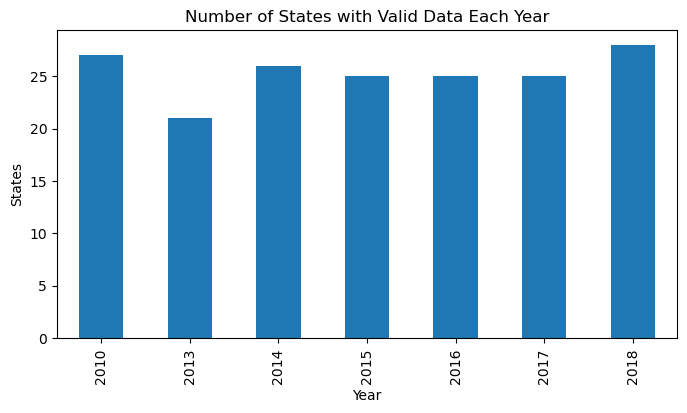

In [6]:
states_per_year = asth.groupby("YearStart")["LocationAbbr"].nunique()

states_per_year.plot(kind="bar", figsize=(8,4))
plt.title("Number of States with Valid Data Each Year")
plt.ylabel("States")
plt.xlabel("Year")
plt.show()

**The number of states with valid data varies between 21–28 per year due to CDC suppression rules.
This justifies the need for a hierarchical model that can handle uneven data availability across states.**

--------------------------------------------------------------------------------------------------------------------------------

**The distribution histogram of hospitalization rates** （Distribution / distribution of prior Check）

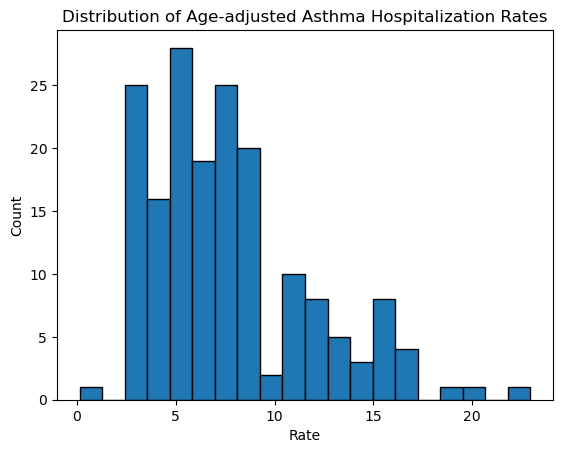

In [7]:
plt.hist(asth["DataValue"], bins=20, edgecolor='black')
plt.title("Distribution of Age-adjusted Asthma Hospitalization Rates")
plt.xlabel("Rate")
plt.ylabel("Count")
plt.show()

**The distribution of observed age-adjusted asthma hospitalization rates shown in the histogram is continuous, unimodal, and fairly symmetric around its center, with most values falling between roughly 4 and 10 hospitalizations per 10,000 residents. Although a small number of higher observations create a mild right tail, the overall shape remains smooth and bell-shaped rather than heavily skewed or multi-modal. This makes the Normal distribution a reasonable likelihood choice for modeling the observed rates**

----------------------------------------------------------------------------------------------------------------

**Boxplot:Distribution of observed values in each state**
- The differences between states
- Variance within each state
- Which states are particularly noisy 

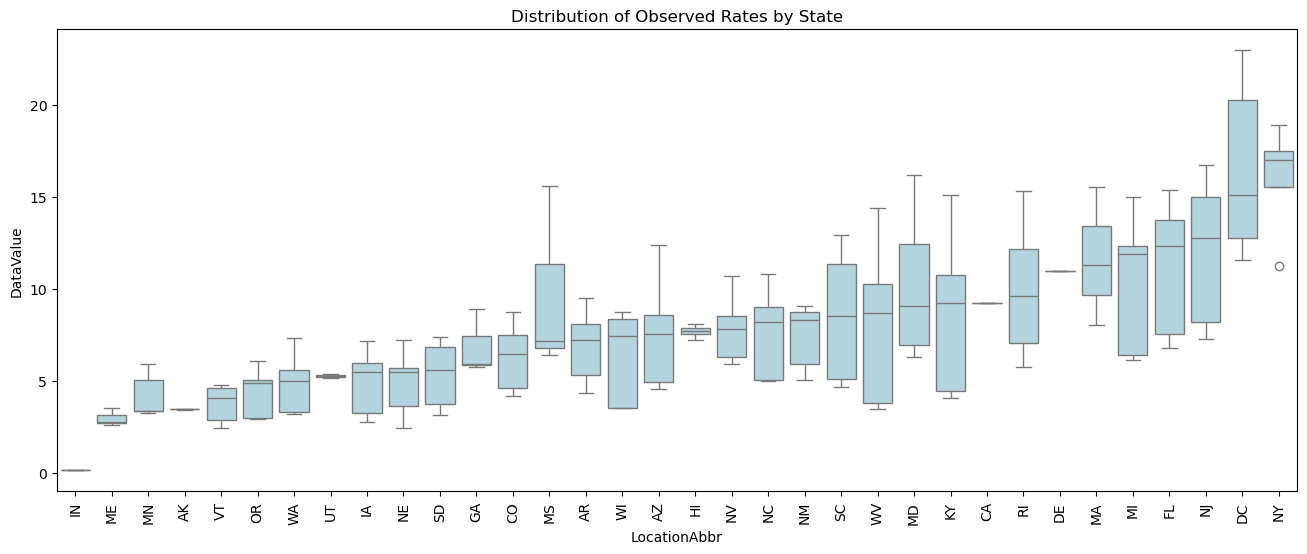

In [8]:
plt.figure(figsize=(16,6))
sort_idx = asth.groupby('LocationAbbr')['DataValue'].median().sort_values().index
sns.boxplot(x='LocationAbbr', y='DataValue', data=asth, order=sort_idx, color='lightblue')
plt.title("Distribution of Observed Rates by State")
plt.xticks(rotation=90)
plt.show()

**The boxplot shows that states differ in their year-to-year hospitalization rates, with some states fluctuating more than others.**

-------------------------------------------------

**CI width VS Observed data plot**

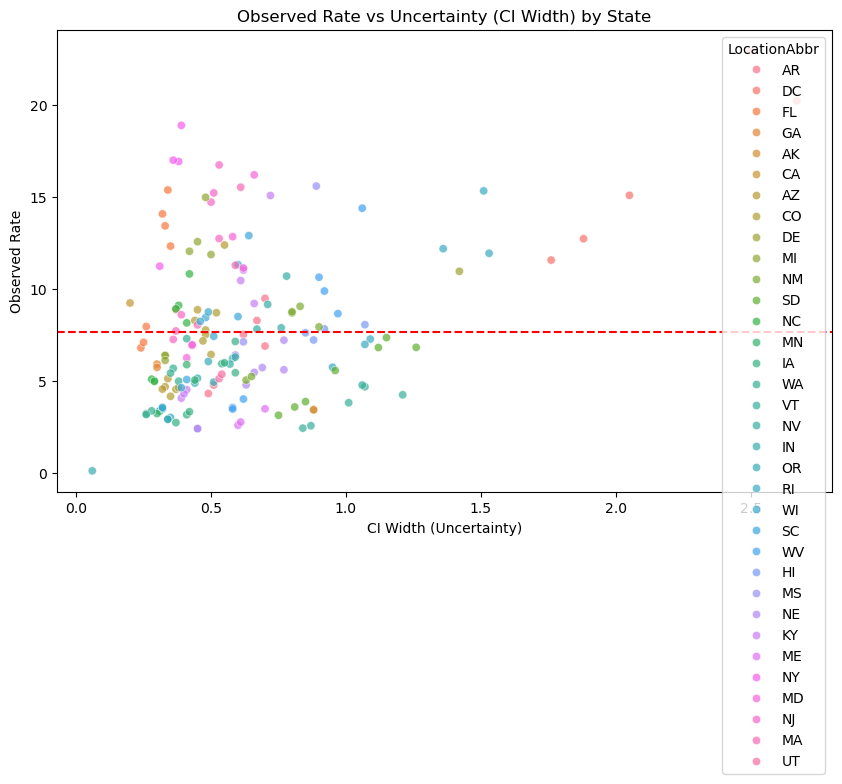

LocationAbbr
DC    2.172000
DE    1.420000
RI    1.251667
VT    1.010000
SD    0.985714
Name: CI_Width, dtype: float64

In [9]:
asth["CI_Width"] = asth["HighConfidenceLimit"] - asth["LowConfidenceLimit"]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=asth,
    x="CI_Width",
    y="DataValue",
    hue="LocationAbbr",      
    alpha=0.7             
)
plt.axhline(asth["DataValue"].mean(), color="red", linestyle="--")
plt.title("Observed Rate vs Uncertainty (CI Width) by State")
plt.xlabel("CI Width (Uncertainty)")
plt.ylabel("Observed Rate")
plt.show()

asth.groupby("LocationAbbr")["CI_Width"].mean().sort_values(ascending=False).head(5)

**All of these states are relatively small ones in the United States. And these states all exhibited the phenomenon of wide confidence intervals.**

----------------

**Conclusion of Discovery(Summary of Key Patterns from EDA)**

Our exploratory analysis reveals several important patterns that motivate the use 
of a Bayesian hierarchical model. First, data coverage is uneven across years, 
with only 21–28 states contributing valid observations annually, indicating that 
the dataset is sparse and unbalanced. Second, the distribution of hospitalization 
rates is strictly positive, mildly right-skewed, and displays occasional extreme 
values. Third, the boxplot shows substantial differences in year-to-year 
variability across states, but this temporal fluctuation alone does not distinguish 
true underlying differences from noise. Most importantly, the CI-width plot shows 
a strong relationship between measurement uncertainty and deviation from the 
national average: small-population states have much wider confidence intervals and 
their observed rates are far more likely to appear as extreme highs or lows.

Together, these patterns indicate that raw observed rates are heavily influenced 
by sampling noise, especially in smaller states, and cannot be taken as direct 
measures of true underlying asthma burden. A Bayesian hierarchical model naturally 
addresses these issues by pooling information across states and shrinking noisy, 
high-uncertainty estimates toward the population mean, yielding more stable and 
credible state-level estimates.


-------

##  Components of the Bayesian Hierarchical Model

To estimate each state’s true underlying asthma hospitalization rate, we construct a **Normal–Normal Bayesian Hierarchical Model**. This framework separates measurement noise from true epidemiological variation, allowing states with noisy observations to borrow statistical strength from states with more precise data. Below we summarize each component of the model.

###  Likelihood
The CDI-reported age-adjusted hospitalization rate for each state-year pair is treated as a noisy measurement of that state’s true underlying rate.

The uncertainty of each observation is encoded in its reported 95% confidence interval, which we convert into a measurement standard deviation $\sigma_i$. Formally, for observation $i$ belonging to state $s[i]$:

$$
y_i \mid \theta_{s[i]}, \sigma_i \sim \mathcal{N}(\theta_{s[i]}, \sigma_i^2)
$$

$$
\sigma_i = \frac{\text{HighCI} - \text{LowCI}}{2 * 1.96}
$$

###  Modeling the true rates across states
We assume each state has its own true asthma hospitalization rate $\theta_s$, but these rates are not independent. Instead, they arise from a shared population distribution centered at a national mean $\mu$, with between-state variability controlled by $\tau$:

$$
\theta_s \mid \mu, \tau \sim \mathcal{N}(\mu, \tau^2), \qquad s = 1,\dots,S
$$

This layer induces **partial pooling**:
* States with precise data (narrow CIs) influence their own estimates strongly.
* States with noisy data are pulled toward the national mean $\mu$.
* The degree of shrinkage is governed by $\tau$.
* This structure is essential for producing stable estimates despite uneven data quality.

### 3. Hyperpriors: Prior beliefs on national-level parameters
The parameters $\mu$ and $\tau$ describe the overall distribution of true asthma hospitalization rates across states. Based on EDA, we place weakly informative hyperpriors that regularize the model without overwhelming the data.

**National mean**
$$
\mu \sim \mathcal{N}(\mu_0,\ \sigma_0^2)
$$
* The histogram shows most observations fall between 4–10. -> setting $\mu_0 = 7$
* A mean of 7 with a wide SD of 5 captures plausible values while permitting uncertainty. -> $\sigma_0 = 5$


**Between-state variation**
$$
\tau \sim \text{HalfNormal}(\gamma)
$$

 $$Set :\gamma = 5$$
* Ensures $\tau \ge 0$. —> HalfNormal
* We set $\gamma = 5$ because exploratory analysis shows that states differ by roughly 5–10 hospitalization-rate units, making 5 the appropriate scale for capturing realistic between-state variation.
* This value provides a weakly informative prior: it is wide enough to accommodate high- and low-burden states while still constraining $\tau$ to plausible magnitudes derived from the observed data.

### 4. Posterior: What the model ultimately estimates
The posterior distribution combines the **likelihood $\times$ priors**, producing updated beliefs about all unknown quantities after observing the data:

$$
p(\theta_{1:S}, \mu, \tau \mid \mathbf{y}) \propto \left[\prod_{i=1}^{N} \mathcal{N}(y_i \mid \theta_{s[i]}, \sigma_i^2)\right] \times \left[\prod_{s=1}^{S} \mathcal{N}(\theta_s \mid \mu, \tau^2)\right] \times \mathcal{N}(\mu \mid 7, 5^2)\,\text{HalfNormal}(\tau \mid 5)
$$

This posterior yields:
* **State-specific posterior means $\theta_s$:** Our best estimates of each state's true hospitalization burden.
* **Posterior for $\mu$:** The national average asthma hospitalization rate.
* **Posterior for $\tau$:** The degree of true variability across states.

These posterior summaries directly answer the research question by quantifying how asthma burden varies geographically across the U.S., while correcting for noisy observations.


-----------------

### Prepare Data

In [10]:
#Compute sigma
asth_NN = asth.copy()
asth_NN['sigma'] = (asth_NN['HighConfidenceLimit'] - asth_NN['LowConfidenceLimit']) / (2 * 1.96)

#Prevent sigma = 0 or very small number
asth_NN["sigma"] = asth_NN["sigma"].clip(lower=1e-4)

#Encode LocationAbbr
state_cats = asth_NN["LocationAbbr"].astype("category")
asth_NN['state_id'] = state_cats.cat.codes
state_names = list(state_cats.cat.categories)
n_states = len(state_names)

state_id_to_name = {i: state_names[i] for i in range(n_states)}
print(state_id_to_name)


{0: 'AK', 1: 'AR', 2: 'AZ', 3: 'CA', 4: 'CO', 5: 'DC', 6: 'DE', 7: 'FL', 8: 'GA', 9: 'HI', 10: 'IA', 11: 'IN', 12: 'KY', 13: 'MA', 14: 'MD', 15: 'ME', 16: 'MI', 17: 'MN', 18: 'MS', 19: 'NC', 20: 'NE', 21: 'NJ', 22: 'NM', 23: 'NV', 24: 'NY', 25: 'OR', 26: 'RI', 27: 'SC', 28: 'SD', 29: 'UT', 30: 'VT', 31: 'WA', 32: 'WI', 33: 'WV'}


### Construct Model

In [11]:
def fit_NN_model(y_observed, mu_0, sigma_0, gamma, n_states, state_id):
    with pm.Model() as asthma_hier_normal:
        # ---- Hyperpriors: μ ~ N(mu_0, sigma_0^2), τ ~ HalfNormal(gamma) ----
        mu = pm.Normal('mu', mu = mu_0, sigma = sigma_0)
        tau = pm.HalfNormal("tau", sigma = gamma)
    
        #---- State-level prior: theta_s | mu, tau ~ N(mu, tau^2) ----
        theta = pm.Normal('theta', mu = mu, sigma = tau, shape = n_states)
    
        # ---- Likelihood: y_i | theta_{s[i]}, sigma_i ~ N(theta_{s[i]}, sigma_i^2) ----
        y_obs = pm.Normal(
        "y_obs",
        mu = theta[state_id],
        sigma = sigma,
        observed = y_observed
        )
    
        trace = pm.sample(draw = 2000, tune=2000, target_accept=0.95,progressbar=False, random_seed = 42)

    return trace


In [12]:
#By the observation of EDA
mu_0 = 7
sigma_0 = 5
gamma = 5

#Extract value for model
y_observed = asth_NN["DataValue"].values
sigma = asth_NN["sigma"].values
state_id = asth_NN["state_id"].values

trace_NN_gamma5 = fit_NN_model(y_observed, mu_0, sigma_0, gamma, n_states, state_id)

az.summary(trace_NN_gamma5, var_names=["mu", "tau"])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, tau, theta]
Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 6 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,6.975,0.585,5.822,8.068,0.007,0.012,7430.0,2770.0,1.0
tau,3.393,0.437,2.630,4.216,0.005,0.010,8866.0,2881.0,1.0


**Summarize state-level posterior estimates for theta**
- Extract posterior draws of theta from the fitted model
- Compute the posterior mean for each state
- Compute the 95% Highest Density Interval (HDI) for each state
- Assemble a DataFrame with state, posterior mean, and 95% HDI bounds,


In [13]:
def theta_mean_df(trace):
    #Extract theta form posterior
    theta_post = trace.posterior["theta"]
    theta_mean = theta_post.mean(dim=("chain", "draw")).values
    #Build 95% HDI
    theta_hdi = az.hdi(theta_post, hdi_prob=0.95)
    
    #Extract lower/upper bound
    theta_da = theta_hdi["theta"]
    theta_low = theta_da.sel(hdi = 'lower').values
    theta_up = theta_da.sel(hdi = 'higher').values
    
    #Create DF for summary
    theta_df = pd.DataFrame({
        "state": state_names,
        "theta_mean": theta_mean,
        "theta_95%HDI_lower": theta_low,
        "theta_95%HDI_upper": theta_up,
    })

    return theta_df

theta_mean_df(trace_NN_gamma5)

,state,theta_mean,theta_95%HDI_lower,theta_95%HDI_upper
0,AK,3.463129,3.162390,3.765576
1,AR,6.385805,6.264924,6.501296
2,AZ,6.454535,6.380110,6.527848
3,CA,9.249332,9.156136,9.342134
4,CO,5.749286,5.660629,5.825665
5,DC,15.201894,14.734305,15.693962
6,DE,10.921122,10.201092,11.621042
7,FL,10.066634,10.011721,10.120630
8,GA,6.593924,6.499775,6.682728
9,HI,7.655972,7.427614,7.885301


## Try other hyperparameters ($\gamma = 3$)

In [14]:
trace_NN_gamma3 = fit_NN_model(y_observed, mu_0, sigma_0, 3, n_states, state_id)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, tau, theta]
Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 6 seconds.


In [15]:
summ_g5 = az.summary(trace_NN_gamma5, var_names=["mu", "tau"], hdi_prob=0.95)
summ_g3 = az.summary(trace_NN_gamma3, var_names=["mu", "tau"], hdi_prob=0.95)
print("gamma = 5")
display(summ_g5)

print("gamma = 3")
display(summ_g3)

gamma = 5


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,6.975,0.585,5.720,8.068,0.007,0.012,7430.0,2770.0,1.0
tau,3.393,0.437,2.583,4.237,0.005,0.010,8866.0,2881.0,1.0


gamma = 3


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,6.976,0.586,5.848,8.106,0.007,0.011,7679.0,2634.0,1.0
tau,3.353,0.416,2.610,4.199,0.005,0.008,7995.0,2644.0,1.0


,state,theta_mean_g5,theta_95%HDI_lower_g5,theta_95%HDI_upper_g5,theta_mean_g3,theta_95%HDI_lower_g3,theta_95%HDI_upper_g3,g5-g3 diff,abs_diff
5,DC,15.201894,14.734305,15.693962,15.211496,14.736866,15.663667,-0.009602,0.009602
6,DE,10.921122,10.201092,11.621042,10.926669,10.241606,11.626554,-0.005547,0.005547
30,VT,3.556763,3.361832,3.763176,3.558925,3.364959,3.759333,-0.002161,0.002161
29,UT,5.260329,5.079328,5.445821,5.258699,5.076106,5.445060,0.001630,0.001630
8,GA,6.593924,6.499775,6.682728,6.595448,6.503638,6.683177,-0.001524,0.001524


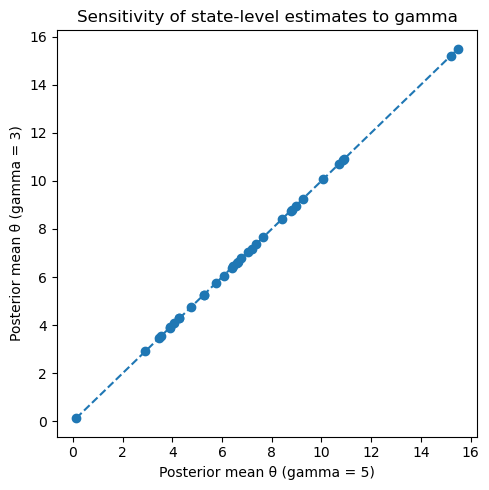

In [16]:
gamma3_df = theta_mean_df(trace_NN_gamma3)
gamma5_df = theta_mean_df(trace_NN_gamma5)

#Merge these two df on state
theta_comp = (gamma5_df.merge(gamma3_df, on="state", suffixes=("_g5", "_g3")))
theta_comp['g5-g3 diff'] = theta_comp['theta_mean_g5'] - theta_comp['theta_mean_g3']
theta_comp['abs_diff'] = abs(theta_comp['theta_mean_g5'] - theta_comp['theta_mean_g3'])

plt.figure(figsize=(5,5))
plt.scatter(theta_comp["theta_mean_g5"], theta_comp["theta_mean_g3"])
plt.plot([theta_comp["theta_mean_g5"].min(), theta_comp["theta_mean_g5"].max()],
         [theta_comp["theta_mean_g5"].min(), theta_comp["theta_mean_g5"].max()],
         linestyle="--")
plt.xlabel("Posterior mean θ (gamma = 5)")
plt.ylabel("Posterior mean θ (gamma = 3)")
plt.title("Sensitivity of state-level estimates to gamma")
plt.tight_layout()

theta_comp.sort_values('abs_diff', ascending = False).head()


### Conclusion
The model is **robust** to reasonable changes in the hyperparameter $\gamma$. The data's **likelihood dominates the prior**, and the inferred state-level hospitalization rates remain stable when the hyperparameter on the between-state standard deviation is perturbed. We can confidently proceed with the results from the main specification ($\gamma=5$).

--------

## Method

**Q:Draw a graphical model, clearly indicating which variables are observed. Provide descriptions of any hidden variables you’re trying to estimate.**

![](Image_20251205154258.jpg)

**Q:Clearly describe the groups in your dataset, and explain why a hierarchical model is a good choice for modeling variability across the groups.**

In our dataset, the natural grouping structure is U.S. states. For each state, we observe multiple years of age-adjusted asthma hospitalization rates, and each observation comes with a state-specific measurement uncertainty derived from its 95% confidence interval. Thus, the data consist of repeated noisy measurements within each state and substantial variability across states.

A hierarchical model is appropriate for two key reasons:

(1) Unequal data quality across states.
States differ dramatically in population size and number of hospitalizations. Smaller states (e.g., VT, DE, RI) report wider confidence intervals and more volatile year-to-year rates, while larger states (e.g., CA, FL, NY) provide much more stable estimates. This heterogeneity in measurement noise makes direct comparison of observed rates unfair and motivates a model that can treat noisy states differently from well-measured ones.

(2) States share a common underlying distribution.
While each state has its own true hospitalization rate, states are not independent of one another; they reflect a shared national context. A hierarchical prior allows states to “borrow strength” from the overall national distribution. Well-measured states contribute precise information about the population-level mean and variance, while noisy states are shrunk toward this shared structure. This partial pooling produces more stable and interpretable estimates of each state’s true asthma burden.

Together, these features make a hierarchical model the most appropriate framework for capturing both within-state uncertainty and between-state variability, while preventing extreme estimates that arise merely from sampling noise.

**Q:You must implement a full hierarchical model and describe the group-level data, group-
level parameters, and global parameters and what they mean. Any model simpler than this might be penalized: if you aren’t sure if your model is too simple, just come ask.**

We employ a **Normal-Normal Bayesian Hierarchical Model** to separate measurement noise ($\sigma_i$) from true between-state variability ($\tau$). The structure is summarized below:

 **1. Observation Layer (Likelihood)**
* **Function:** Links the observed rate ($y_i$) to the state's true latent rate ($\theta_{s[i]}$).
* **Mechanism:** Uses known measurement uncertainty ($\sigma_i$) derived from the reported CIs.

$$
y_i \mid \theta_{s[i]}, \sigma_i \sim \mathcal{N}(\theta_{s[i]}, \sigma_i^2)
$$

 **2. State Layer (Hierarchical Prior)**
* **Function:** Implements **Partial Pooling** by assuming all true state rates ($\theta_s$) are drawn from a common national distribution.
* **Mechanism:** Unstable estimates are shrunk towards the national mean ($\mu$).

$$
\theta_s \mid \mu, \tau \sim \mathcal{N}(\mu, \tau^2), \quad s = 1,\dots,S
$$

 **3. Global Parameter Layer (Hyperpriors)**
* **Function:** Sets weakly informative priors on the national mean ($\mu$) and between-state standard deviation ($\tau$), informed by EDA.

$$
\mu \sim \mathcal{N}(\mu, \tau^2), \qquad \tau \sim \text{HalfNormal}(\gamma)
$$


**Full Posterior Distribution**

The model's final posterior distribution, representing our updated beliefs about all parameters ($\theta_s, \mu, \tau$), is proportional to the product of the likelihood and all prior components:

$$
p(\theta_{1:S}, \mu, \tau \mid \mathbf{y}) 
\propto
\left[\prod_{i=1}^{N} \mathcal{N}(y_i \mid \theta_{s[i]}, \sigma_i^2)\right]
\times
\left[\prod_{s=1}^{S} \mathcal{N}(\theta_s \mid \mu, \tau^2)\right]
\times
\mathcal{N}(\mu \mid 7, 5^2)\,\text{HalfNormal}(\tau \mid 5)
$$

**Q:Justify and explain your choice of each prior and conditional distribution in the model (Gaussian, Beta, etc.).**

In our hierarchical model, each distribution was chosen to match both the structure of the CDC asthma dataset and the statistical behavior revealed in our exploratory analysis. We model the observed hospitalization rates using a Normal likelihood because the CDC reports symmetric confidence intervals, which implicitly assume normally distributed measurement error. The empirical histogram also shows a unimodal, approximately bell-shaped distribution with only mild right skew, indicating that the Normal likelihood is an appropriate and stable choice for continuous epidemiological rates.

At the state level, we place a Normal prior on each state’s true underlying rate. This choice reflects the fact that state-to-state differences appear continuous and roughly symmetric rather than clustered or multi-modal. A Normal prior also induces partial pooling: states with precise observations remain close to their observed values, while states with high uncertainty are nudged toward the overall national mean. This behavior is desirable because it stabilizes estimates for small-population states without erasing genuine geographic differences.

For the national mean parameter, we use a weakly informative Normal prior centered near the empirical average hospitalization rate observed across states. This prior is intentionally broad, serving only to regularize the model while allowing the data to dominate the final posterior. For the between-state variability parameter, we adopt a Half-Normal prior, which is standard for quantities that must be non-negative. The Half-Normal prior places reasonable weight on both small and moderate levels of heterogeneity, consistent with the range of variability observed in our EDA, without forcing the model toward unrealistically large or small variance.

Together, these choices create a coherent Bayesian hierarchical model that respects the data-generating assumptions of the CDC measurements, captures meaningful geographic variation, and provides stable shrinkage for noisy states while avoiding overly strong or arbitrary prior assumptions.

## Result

Case Where $\gamma = 5$ 

**Q:Explain how you chose the hyperparameters for your prior distribution: did you useempirical Bayes? A full hierarchical model? Why?**

We used a fully Bayesian hierarchical model with population-level hyperpriors rather than fixing the hyperparameters via empirical Bayes. The choice of hyperparameters was guided by exploratory data analysis (EDA).

**Q:Summarize and interpret your results. Are there any counterintuitive findings or surprises?**

We got: $$\mu \approx 6.98 \quad (95\% \text{HDI}: 5.82, 8.07)$$ $$\tau \approx 3.39 \quad (95\% \text{HDI}: 2.63, 4.22)$$

This indicates moderate-to-large heterogeneity across states.
State-level posterior means ranged approximately from 0.13 (IN) to about 7.19 (SC).
Small-sample states experienced noticeable shrinkage towards the national mean, which stabilizes noisy raw estimates

A somewhat counterintuitive finding is that several states with high observed rates (due to sparse data) had substantially reduced posterior estimates after pooling. This highlights the value of hierarchical modeling: the model protects against over-interpreting noisy measurements

**Q:Provide a credible interval for at least one hidden variable in the model, and provide clearquantitative statements of the uncertainty in plain English.**

South Carolina (SC):

- Posterior mean: 7.19

- 95% credible interval: [7.08, 7.30]

Based on the model and available data, we estimate that the true underlying asthma hospitalization rate in South Carolina is about 7 cases per 10,000 people. There is a 95% probability that the true rate ($\theta_{SC}$) lies within the 95% HDI of [7.08, 7.30]. This interval successfully reflects the combination of local measurement uncertainty and the true between-state variation, as intended by our hierarchical model

**Q:Choose at least one hyperparameter and test the sensitivity of your findings to changes in that hyperparameter. Explain why your results are, or are not, robust to changes in this parameter. If they are not, either report the uncertainty in your results associated with this choice, or, explain how the parameter could be estimated in order to eliminate this uncertainty.**

To assess the robustness of the hierarchical model, we re-estimated the Normal--Normal model using an alternative hyperprior for the between-state standard deviation, $\tau$

with $\gamma = 5$ in the main specification and $\gamma = 3$ as the alternative. A smaller $\gamma$ places a stronger prior toward low between-state heterogeneity (i.e., assuming states are more similar).


**Results for State-Level Parameters ($\theta_s$)**

State-level posterior means ($\theta_s$) showed similarly minimal sensitivity. The largest absolute difference across all $S$ states was calculated less then 0.01

This difference is negligible, indicating that the inferred true state rates are almost entirely determined by the data's likelihood, rather than the initial prior belief on the overall state variability ($\tau$). A scatterplot of $\theta^{(5)}_s$ versus $\theta^{(3)}_s$ would show the points lying almost perfectly on the $45^{\circ}$ line (the line of equality).

#### Conclusion

The model is **robust** to reasonable changes in the hyperparameter $\gamma$. The data's **likelihood dominates the prior**, and the inferred state-level hospitalization rates remain stable when the hyperparameter on the between-state standard deviation is perturbed. We can confidently proceed with the results from the main specification ($\gamma=5$).